In [2]:
import pandas as pd
import numpy as np


PATH = '/content/feature_engineered_dataset.zip'


df = pd.read_csv(PATH)

print(df.shape)
print(df.columns.tolist())
print(df.isna().sum()[lambda s: s > 0])

(2047446, 26)
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Timestamp', 'Datetime', 'Hour', 'Day', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'Weekend', 'Lag_1', 'Lag_24', 'Lag_168', 'RollingMean_24', 'RollingStd_24', 'Difference', 'PctChange', 'Peak']
Series([], dtype: int64)


In [3]:
# Make sure Date is a proper date type
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# Build daily features
daily = df.groupby('Date').agg(
    avg_consumption=('Global_active_power', 'mean'),
    peak_consumption=('Global_active_power', 'max'),
    min_consumption=('Global_active_power', 'min'),
    std_consumption=('Global_active_power', 'std'),      # variability
    avg_intensity=('Global_intensity', 'mean'),
    avg_voltage=('Voltage', 'mean'),
    avg_sub1=('Sub_metering_1', 'mean'),
    avg_sub2=('Sub_metering_2', 'mean'),
    avg_sub3=('Sub_metering_3', 'mean'),
    is_weekend=('Weekend', 'max'),                        # 0 or 1 for that day
).reset_index()

# Add day-of-week average pattern (morning vs evening usage)
morning = df[df['Hour'].between(6, 11)].groupby('Date')['Global_active_power'].mean().rename('avg_morning')
evening = df[df['Hour'].between(17, 22)].groupby('Date')['Global_active_power'].mean().rename('avg_evening')
night   = df[df['Hour'].between(0, 5)].groupby('Date')['Global_active_power'].mean().rename('avg_night')

daily = daily.merge(morning, on='Date', how='left')
daily = daily.merge(evening, on='Date', how='left')
daily = daily.merge(night, on='Date', how='left')

print(daily.shape)
daily.head()

(1432, 14)


,Date,avg_consumption,peak_consumption,min_consumption,std_consumption,avg_intensity,avg_voltage,avg_sub1,avg_sub2,avg_sub3,is_weekend,avg_morning,avg_evening,avg_night
0,2006-12-16,2.613088,4.122,0.284,0.851743,11.204386,237.894123,0.000000,0.166667,9.241228,1,NaN,2.810048,NaN
1,2006-12-17,2.354486,7.064,0.206,1.205795,9.999028,240.087028,1.411806,2.907639,9.264583,1,2.243811,2.988756,2.115639
2,2006-12-18,1.530435,6.158,0.202,1.005074,6.421667,241.231694,0.738194,1.820139,9.734722,0,1.607244,2.355172,0.417317
3,2006-12-19,1.157079,7.840,0.194,1.237602,4.926389,241.999313,0.582639,5.279167,4.303472,0,1.806256,1.876950,0.410033
4,2006-12-20,1.545658,5.988,0.202,1.320968,6.467361,242.308062,0.000000,1.838889,9.765972,0,1.752678,2.823244,0.394100


In [4]:
# Check missing values
print(daily.isna().sum())

# These NaNs are from partial days (first day starts mid-evening, last day may end early)
# Safest fix: drop rows where any of the pattern columns are missing
daily_clean = daily.dropna().reset_index(drop=True)

print("Before:", daily.shape, " After:", daily_clean.shape)

Date                 0
avg_consumption      0
peak_consumption     0
min_consumption      0
std_consumption      0
avg_intensity        0
avg_voltage          0
avg_sub1             0
avg_sub2             0
avg_sub3             0
is_weekend           0
avg_morning         10
avg_evening          5
avg_night            6
dtype: int64
Before: (1432, 14)  After: (1420, 14)


In [5]:
from sklearn.preprocessing import StandardScaler

# Select the features that describe consumption behavior (drop Date and is_weekend for now —
# is_weekend is a 0/1 flag, we'll use it later to interpret clusters, not to cluster on it directly)
feature_cols = [
    'avg_consumption', 'peak_consumption', 'min_consumption', 'std_consumption',
    'avg_intensity', 'avg_voltage', 'avg_sub1', 'avg_sub2', 'avg_sub3',
    'avg_morning', 'avg_evening', 'avg_night'
]

X = daily_clean[feature_cols].copy()

# Scale (K-Means uses distance, so features must be on the same scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X_scaled[:3])

(1420, 12)
[[ 3.0337872   0.99938946  0.08588176  0.91685882  3.11721401 -0.37128276
   0.26358948  1.10796606  1.09874912  1.85325011  1.85550422  4.61007569]
 [ 1.05513298  0.45800886  0.0179797   0.2718502   1.0421134   0.19256467
  -0.34600601  0.3603381   1.28280402  0.64751369  1.03839727 -0.24762083]
 [ 0.15865789  1.46308851 -0.11782442  1.01906907  0.17475567  0.57068301
  -0.48677857  2.7383297  -0.8434786   1.02446548  0.42165329 -0.26845328]]


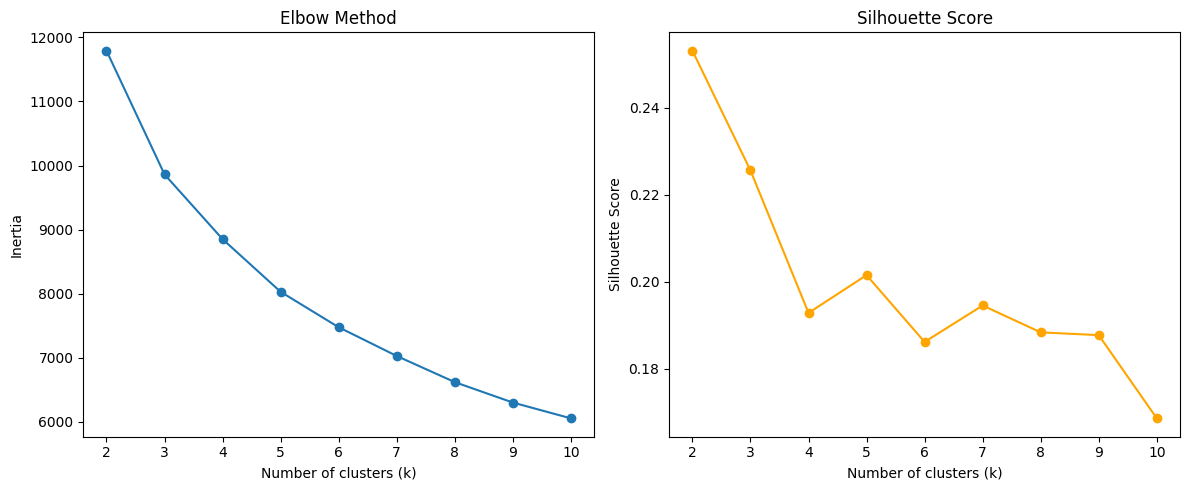

k=2: inertia=11791.9, silhouette=0.253
k=3: inertia=9861.0, silhouette=0.226
k=4: inertia=8850.8, silhouette=0.193
k=5: inertia=8028.8, silhouette=0.201
k=6: inertia=7475.9, silhouette=0.186
k=7: inertia=7027.4, silhouette=0.195
k=8: inertia=6619.3, silhouette=0.188
k=9: inertia=6300.7, silhouette=0.188
k=10: inertia=6054.0, silhouette=0.169


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K_range = range(2, 11)   # test k = 2 to 10

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.tight_layout()
plt.show()

# Print scores as a table too
for k, i, s in zip(K_range, inertia, silhouette):
    print(f"k={k}: inertia={i:.1f}, silhouette={s:.3f}")

In [7]:
# Final K-Means model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
daily_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Check how many days fall into each cluster
print(daily_clean['cluster'].value_counts().sort_index())

cluster
0    378
1    575
2    194
3    273
Name: count, dtype: int64


In [8]:
# Average feature values per cluster — this tells us what each cluster "means"
cluster_profile = daily_clean.groupby('cluster')[feature_cols + ['is_weekend']].mean().round(3)
print(cluster_profile)

         avg_consumption  peak_consumption  min_consumption  std_consumption  \
cluster                                                                        
0                  0.871             5.287            0.148            0.857   
1                  1.163             5.468            0.234            0.927   
2                  0.492             2.690            0.165            0.426   
3                  1.671             7.296            0.230            1.346   

         avg_intensity  avg_voltage  avg_sub1  avg_sub2  avg_sub3  \
cluster                                                             
0                3.761      239.277     1.065     1.187     5.469   
1                4.884      241.679     0.957     0.842     7.405   
2                2.140      241.234     0.122     0.438     2.958   
3                7.042      240.960     2.253     3.014     8.320   

         avg_morning  avg_evening  avg_night  is_weekend  
cluster                                      

In [9]:
cluster_names = {
    2: 'Low Consumption Pattern',
    0: 'Moderate Consumption Pattern',
    1: 'High Consumption Pattern',
    3: 'Peak-Heavy Pattern'
}

daily_clean['cluster_name'] = daily_clean['cluster'].map(cluster_names)

print(daily_clean[['Date', 'cluster', 'cluster_name']].head(10))
print(daily_clean['cluster_name'].value_counts())

        Date  cluster              cluster_name
0 2006-12-17        3        Peak-Heavy Pattern
1 2006-12-18        1  High Consumption Pattern
2 2006-12-19        3        Peak-Heavy Pattern
3 2006-12-20        3        Peak-Heavy Pattern
4 2006-12-21        1  High Consumption Pattern
5 2006-12-22        3        Peak-Heavy Pattern
6 2006-12-23        3        Peak-Heavy Pattern
7 2006-12-24        3        Peak-Heavy Pattern
8 2006-12-25        3        Peak-Heavy Pattern
9 2006-12-26        3        Peak-Heavy Pattern
cluster_name
High Consumption Pattern        575
Moderate Consumption Pattern    378
Peak-Heavy Pattern              273
Low Consumption Pattern         194
Name: count, dtype: int64


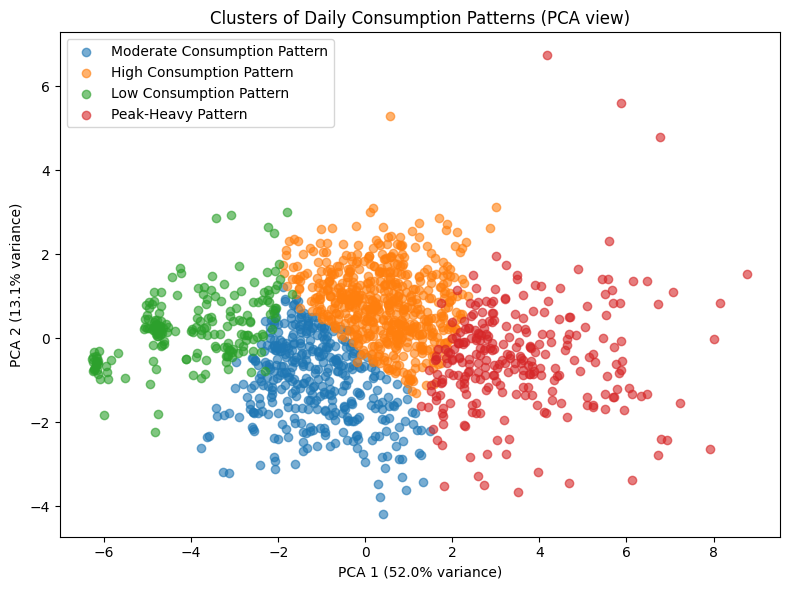

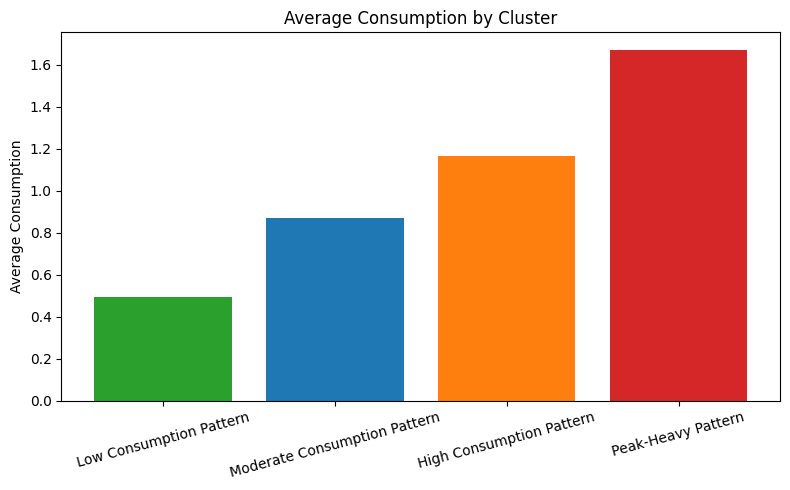

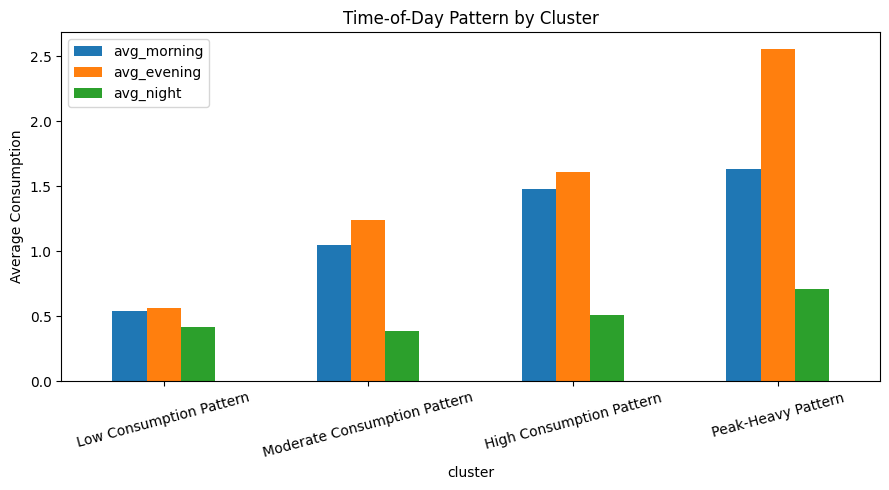

In [10]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Plot 1: PCA scatter plot (reduce 12 features to 2D for visualization) ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green', 3: 'tab:red'}
for c in sorted(daily_clean['cluster'].unique()):
    mask = daily_clean['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=cluster_names[c], color=colors[c], alpha=0.6)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Clusters of Daily Consumption Patterns (PCA view)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Cluster profile bar chart (avg consumption by cluster) ---
plt.figure(figsize=(8, 5))
order = [2, 0, 1, 3]  # low to high
names_ordered = [cluster_names[c] for c in order]
values = [cluster_profile.loc[c, 'avg_consumption'] for c in order]
plt.bar(names_ordered, values, color=[colors[c] for c in order])
plt.ylabel('Average Consumption')
plt.title('Average Consumption by Cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --- Plot 3: Morning/Evening/Night pattern by cluster ---
pattern_cols = ['avg_morning', 'avg_evening', 'avg_night']
cluster_profile[pattern_cols].loc[order].plot(kind='bar', figsize=(9, 5))
plt.xticks(ticks=range(4), labels=names_ordered, rotation=15)
plt.ylabel('Average Consumption')
plt.title('Time-of-Day Pattern by Cluster')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, daily_clean['cluster'])
db_score = davies_bouldin_score(X_scaled, daily_clean['cluster'])

print(f"Silhouette Score (k=4): {sil_score:.3f}")
print(f"Davies-Bouldin Score (k=4): {db_score:.3f}")

# Cluster sizes as % of total
print("\nCluster distribution:")
print((daily_clean['cluster_name'].value_counts(normalize=True) * 100).round(1))

Silhouette Score (k=4): 0.193
Davies-Bouldin Score (k=4): 1.540

Cluster distribution:
cluster_name
High Consumption Pattern        40.5
Moderate Consumption Pattern    26.6
Peak-Heavy Pattern              19.2
Low Consumption Pattern         13.7
Name: proportion, dtype: float64


In [12]:
# 1. Final cluster assignments — this is your main deliverable
clusters_output = daily_clean[['Date', 'cluster', 'cluster_name',
                                 'avg_consumption', 'peak_consumption', 'min_consumption',
                                 'std_consumption', 'is_weekend']].copy()

clusters_output.to_csv('clusters.csv', index=False)
print("Saved clusters.csv:", clusters_output.shape)

# 2. Cluster info/summary table — useful for your report & for Member 2's recommendations
cluster_info = cluster_profile.copy()
cluster_info['cluster_name'] = cluster_info.index.map(cluster_names)
cluster_info['num_days'] = daily_clean['cluster'].value_counts().sort_index()
cluster_info.to_csv('cluster_info.csv')
print("Saved cluster_info.csv:", cluster_info.shape)

# Download both files in Colab
from google.colab import files
files.download('clusters.csv')
files.download('cluster_info.csv')

Saved clusters.csv: (1420, 8)
Saved cluster_info.csv: (4, 15)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

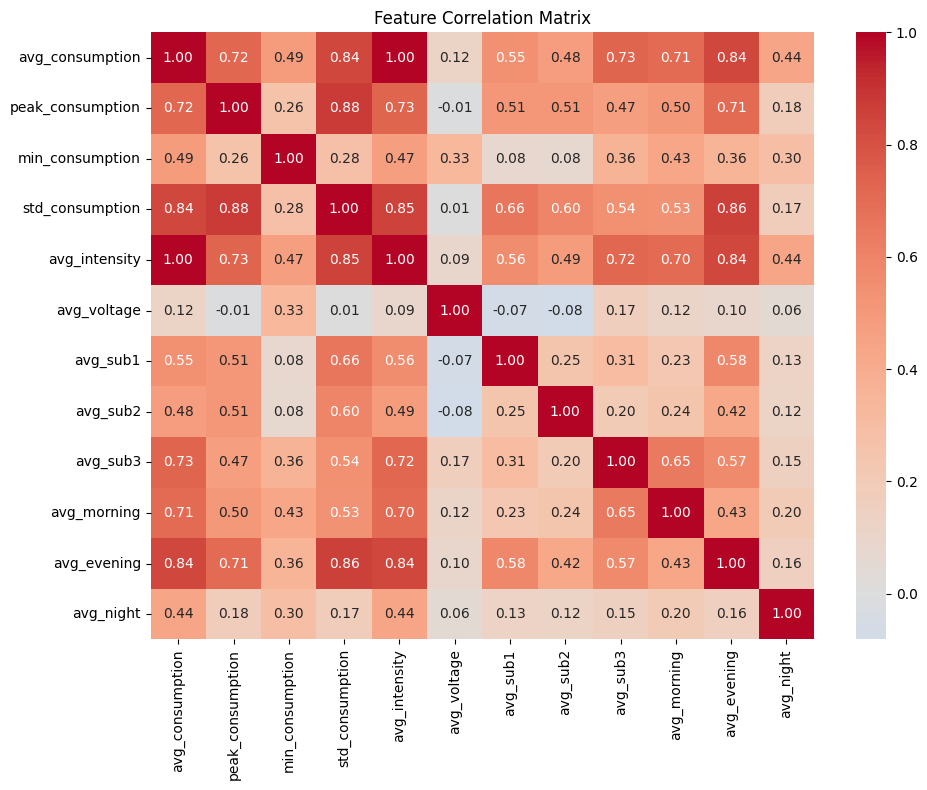

=== k=3 cluster profile ===
            avg_consumption  peak_consumption  min_consumption  \
cluster_k3                                                       
0                     1.125             5.596            0.214   
1                     0.632             3.770            0.157   
2                     1.692             7.275            0.231   

            std_consumption  avg_intensity  avg_voltage  avg_sub1  avg_sub2  \
cluster_k3                                                                    
0                     0.946          4.754      241.118     1.102     1.040   
1                     0.593          2.741      240.206     0.421     0.645   
2                     1.347          7.130      241.007     2.242     3.031   

            avg_sub3  avg_morning  avg_evening  avg_night  
cluster_k3                                                 
0              7.100        1.396        1.600      0.467  
1              3.926        0.766        0.780      0.422  
2    

In [13]:
# --- 1. Feature correlation check ---
import seaborn as sns
corr = daily_clean[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# --- 2. Compare k=3 vs k=4 cluster profiles ---
kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_k3 = kmeans3.fit_predict(X_scaled)

comparison_k3 = daily_clean.copy()
comparison_k3['cluster_k3'] = labels_k3
profile_k3 = comparison_k3.groupby('cluster_k3')[feature_cols].mean().round(3)

print("=== k=3 cluster profile ===")
print(profile_k3)
print("\n=== k=4 cluster profile (chosen) ===")
print(cluster_profile[feature_cols])

print(f"\nk=3 silhouette: {silhouette_score(X_scaled, labels_k3):.3f}")
print(f"k=4 silhouette: {sil_score:.3f}")

In [14]:
feature_cols = [
    'avg_consumption', 'peak_consumption', 'min_consumption', 'std_consumption',
    'avg_voltage', 'avg_sub1', 'avg_sub2', 'avg_sub3',
    'avg_morning', 'avg_evening', 'avg_night'
]   # avg_intensity removed

X = daily_clean[feature_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(1420, 11)


In [15]:
inertia, silhouette = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

for k, i, s in zip(K_range, inertia, silhouette):
    print(f"k={k}: inertia={i:.1f}, silhouette={s:.3f}")

k=2: inertia=11151.4, silhouette=0.238
k=3: inertia=9456.8, silhouette=0.210
k=4: inertia=8460.9, silhouette=0.190
k=5: inertia=7699.0, silhouette=0.201
k=6: inertia=7194.2, silhouette=0.196
k=7: inertia=6754.7, silhouette=0.184
k=8: inertia=6362.6, silhouette=0.185
k=9: inertia=6065.3, silhouette=0.185
k=10: inertia=5822.0, silhouette=0.181


In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
daily_clean['cluster'] = kmeans.fit_predict(X_scaled)
print(daily_clean['cluster'].value_counts().sort_index())

cluster
0    205
1    545
2    286
3    384
Name: count, dtype: int64


In [17]:
cluster_profile = daily_clean.groupby('cluster')[feature_cols + ['is_weekend']].mean().round(3)
print(cluster_profile)

         avg_consumption  peak_consumption  min_consumption  std_consumption  \
cluster                                                                        
0                  0.509             2.751            0.165            0.439   
1                  1.157             5.394            0.237            0.909   
2                  1.647             7.275            0.228            1.342   
3                  0.894             5.395            0.149            0.879   

         avg_voltage  avg_sub1  avg_sub2  avg_sub3  avg_morning  avg_evening  \
cluster                                                                        
0            241.220     0.152     0.443     3.048        0.555        0.583   
1            241.790     0.883     0.774     7.443        1.490        1.581   
2            240.935     2.244     2.989     8.228        1.622        2.537   
3            239.221     1.138     1.231     5.562        1.060        1.288   

         avg_night  is_weekend  
clust

In [18]:
cluster_names = {
    0: 'Low Consumption Pattern',
    3: 'Moderate Consumption Pattern',
    1: 'High Consumption Pattern',
    2: 'Peak-Heavy Pattern'
}

daily_clean['cluster_name'] = daily_clean['cluster'].map(cluster_names)
print(daily_clean['cluster_name'].value_counts())

cluster_name
High Consumption Pattern        545
Moderate Consumption Pattern    384
Peak-Heavy Pattern              286
Low Consumption Pattern         205
Name: count, dtype: int64


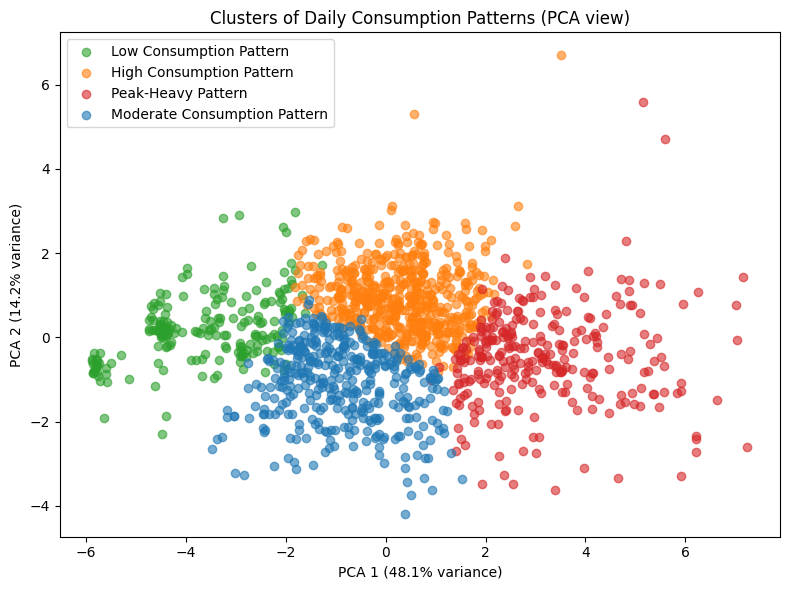

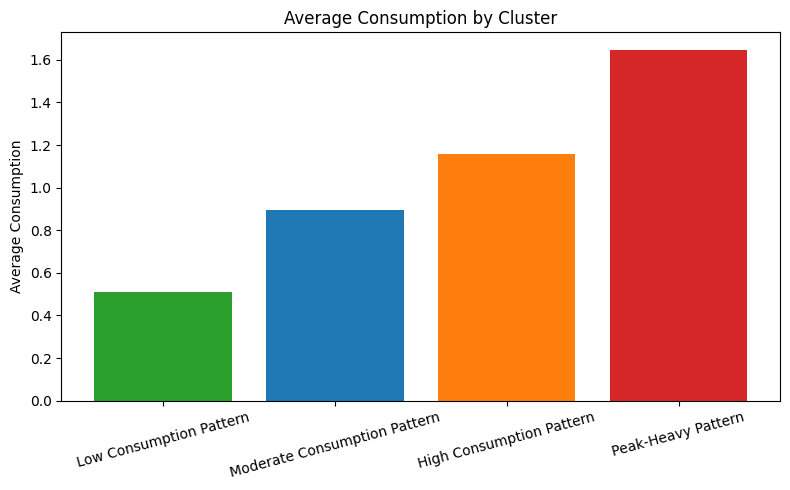

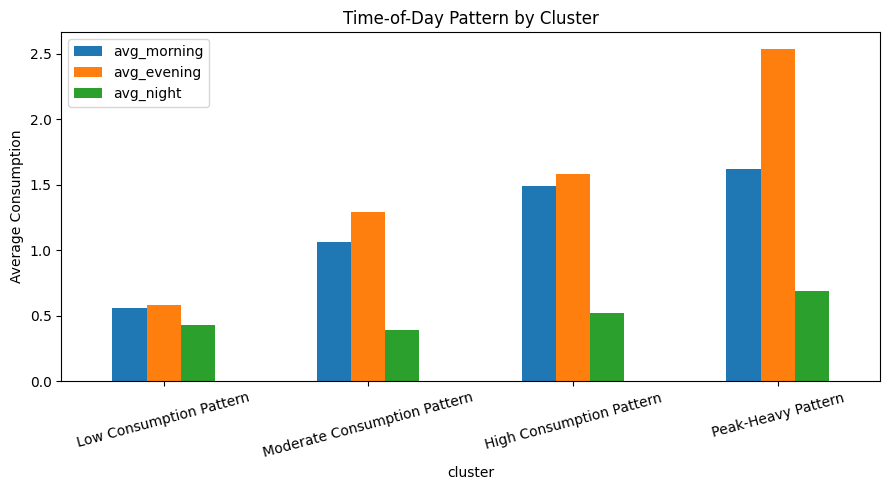

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA scatter
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = {0: 'tab:green', 1: 'tab:orange', 2: 'tab:red', 3: 'tab:blue'}
for c in sorted(daily_clean['cluster'].unique()):
    mask = daily_clean['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=cluster_names[c], color=colors[c], alpha=0.6)
plt.xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Clusters of Daily Consumption Patterns (PCA view)')
plt.legend()
plt.tight_layout()
plt.show()

# Avg consumption bar chart
plt.figure(figsize=(8, 5))
order = [0, 3, 1, 2]  # low to high
names_ordered = [cluster_names[c] for c in order]
values = [cluster_profile.loc[c, 'avg_consumption'] for c in order]
plt.bar(names_ordered, values, color=[colors[c] for c in order])
plt.ylabel('Average Consumption')
plt.title('Average Consumption by Cluster')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Time-of-day pattern
pattern_cols = ['avg_morning', 'avg_evening', 'avg_night']
cluster_profile[pattern_cols].loc[order].plot(kind='bar', figsize=(9, 5))
plt.xticks(ticks=range(4), labels=names_ordered, rotation=15)
plt.ylabel('Average Consumption')
plt.title('Time-of-Day Pattern by Cluster')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X_scaled, daily_clean['cluster'])
db_score = davies_bouldin_score(X_scaled, daily_clean['cluster'])

print(f"Silhouette Score (k=4): {sil_score:.3f}")
print(f"Davies-Bouldin Score (k=4): {db_score:.3f}")
print((daily_clean['cluster_name'].value_counts(normalize=True) * 100).round(1))

Silhouette Score (k=4): 0.190
Davies-Bouldin Score (k=4): 1.559
cluster_name
High Consumption Pattern        38.4
Moderate Consumption Pattern    27.0
Peak-Heavy Pattern              20.1
Low Consumption Pattern         14.4
Name: proportion, dtype: float64


In [21]:
clusters_output = daily_clean[['Date', 'cluster', 'cluster_name',
                                 'avg_consumption', 'peak_consumption', 'min_consumption',
                                 'std_consumption', 'is_weekend']].copy()
clusters_output.to_csv('clusters.csv', index=False)
print("Saved clusters.csv:", clusters_output.shape)

cluster_info = cluster_profile.copy()
cluster_info['cluster_name'] = cluster_info.index.map(cluster_names)
cluster_info['num_days'] = daily_clean['cluster'].value_counts().sort_index()
cluster_info.to_csv('cluster_info.csv')
print("Saved cluster_info.csv:", cluster_info.shape)

from google.colab import files
files.download('clusters.csv')
files.download('cluster_info.csv')

Saved clusters.csv: (1420, 8)
Saved cluster_info.csv: (4, 14)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>